#### Question 1
Program the Heavyball Method

In [412]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [10]:
f = lambda x,y: 100*(y-x**2)**2+(1-x)**2
Df = lambda x,y: np.array([400*x**3-400*x*y-2+2*x,
                           200*y - 200*x**2])
D2g = lambda x,y: np.array([[1200*x**2 - 400*y +2, -400*x],
                            [-400*x, 200]])

In [11]:
from matplotlib.colors import LogNorm  # useful for visualizing this function

def plot_path(path, func, title, window=[-4.5,4.5,-4.5,4.5], contours=np.logspace(-2,6,100), skip=1):
    '''Plots path defined in (N,2) array "path" on a contour plot of "func" in window "window"'''
    plt.figure(figsize=(5,5),dpi=150)
    X = np.linspace(window[0],window[1],300)
    Y = np.linspace(window[2],window[3],300)
    Xmesh, Ymesh = np.meshgrid(X,Y)
    Z = func(Xmesh,Ymesh)
    CS = plt.contourf(Xmesh, Ymesh, Z, contours, cmap='jet', norm = LogNorm())
    # contourf fills the colors. blue is lower value, red is higher value
     
    plt.axis(window)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(title)

    if path is not None:
        for i in range(path.shape[0]-1): # iterate through steps
            if i%skip==0:
                # only plot arrows every "skip" iterations
                plt.arrow(path[i,0],path[i,1],path[i+1,0]-path[i,0],path[i+1,1]-path[i,1],
                          color='k',length_includes_head=True)
    plt.show() 

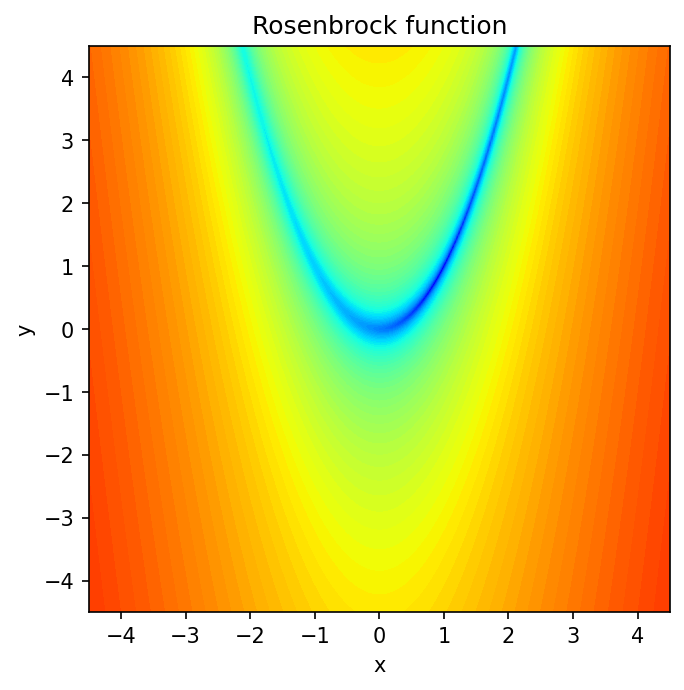

In [12]:
plot_path(None,f,'Rosenbrock function')

In [37]:
D2g(1,1)
eigs, _ = np.linalg.eigh(D2g(1,1))
maxval = eigs[1]
minval = eigs[0]
for i in range(1000):
    x = np.random.uniform(-4.5,4.5,2) # generate a random point
    H = D2g(x[0],x[1])                # and evaluate the Hessian there
    tmp_eigs, _ = np.linalg.eigh(H)
    if tmp_eigs[1]>maxval:                # if eigenvalues larger or smaller, choose those
        maxval = tmp_eigs[1]
    if tmp_eigs[0]<minval:
        minval = tmp_eigs[0]
        
print('Maximum eigenvalue :',maxval,'\nMinimum eigenvalue :',minval)

Maximum eigenvalue : 26034.313774842354 
Minimum eigenvalue : -1585.8887387892491


In [38]:
%%time
x = np.array([-3,-1])
path = [x]
tol = 1e-8
beta = (np.sqrt(maxval)-np.sqrt(eigs[0]))**2/(np.sqrt(maxval)+np.sqrt(eigs[0]))**2  
print('beta = ',beta)
alpha = 4/(np.sqrt(eigs[0])+np.sqrt(maxval))**2                                      
print('alpha = ',alpha)
max_steps = 20000
dx = Df(x[0],x[1])
pk = dx*0      # first update is just gradient descent
i=0
while np.linalg.norm(dx)>tol and i<max_steps:
    pk = -alpha*dx + beta*pk
    xnew = x + pk
    path.append(xnew)
    x = xnew
    i += 1
    dx = Df(x[0],x[1])

path = np.array(path)
print(f'After {i} iterations, approximate minimum is {f(x[0],x[1])} at {x}')

beta =  0.9844555861978365
alpha =  0.00015244689471792422
After 3031 iterations, approximate minimum is 8.39746058177569e-17 at [1.00000001 1.00000002]
CPU times: user 74.4 ms, sys: 15.8 ms, total: 90.2 ms
Wall time: 72.8 ms


#### Question 2

a) Compute optimal solution by solving normal equation

In [413]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import SGDClassifier
data = np.loadtxt("CaCovidInfMarch24toMidJuly.txt")
Xcovid = np.arange(1, len(data) + 1)

In [414]:
X_train = Xcovid[0:90].reshape(-1,1)
X_valid = Xcovid[90:120].reshape(-1,1)
y_train = data[0:90]
y_valid = data[90:120]

In [415]:
linear.fit(X_train,y_train)

LinearRegression()

In [416]:
y_predict = linear.predict(X_valid.reshape(-1,1))
y_predict

array([3358.83673473, 3389.00733134, 3419.17792795, 3449.34852455,
       3479.51912116, 3509.68971777, 3539.86031438, 3570.03091099,
       3600.2015076 , 3630.37210421, 3660.54270082, 3690.71329743,
       3720.88389404, 3751.05449065, 3781.22508726, 3811.39568387,
       3841.56628048, 3871.73687709, 3901.9074737 , 3932.0780703 ,
       3962.24866691, 3992.41926352, 4022.58986013, 4052.76045674,
       4082.93105335, 4113.10164996, 4143.27224657, 4173.44284318,
       4203.61343979, 4233.7840364 ])

In [417]:
print(np.sqrt(mean_squared_error(y_train, linear.predict(X_train.reshape(-1,1)))))
print(np.sqrt(mean_squared_error(y_valid, y_predict)))

417.8948376599642
4263.1047860409435


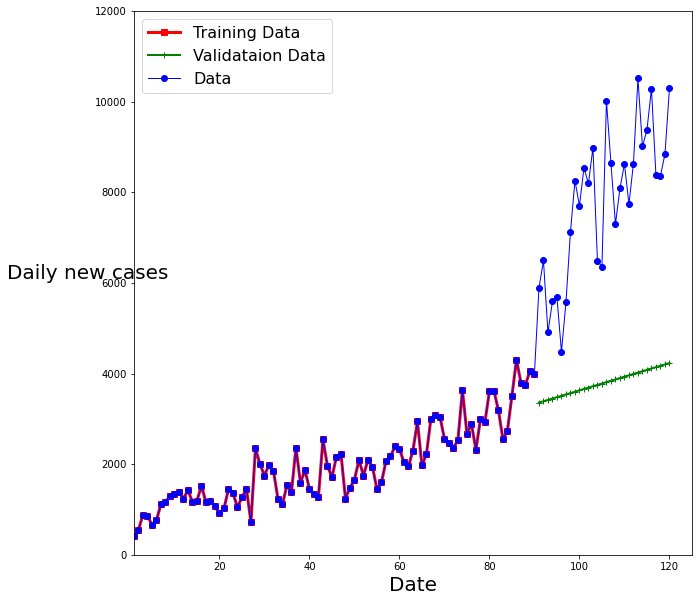

In [418]:
plt.figure(figsize=(10,10))
plt.plot(X_train,y_train, "r-s", linewidth=3,label="Training Data")
plt.plot(X_valid,y_predict, "g-+", linewidth=2, label="Validataion Data")
plt.plot(Xcovid,data, "b-o", linewidth=1, label="Data")
plt.legend(loc="upper left", fontsize=16)
plt.xlabel(r"Date", fontsize=20)
plt.ylabel(r"Daily new cases ", fontsize=20, rotation=0)
plt.axis([1, 125, 0, 12000])
plt.show()

b) compute optimal solution by full batch gradient descent

In [419]:
X_b = np.c_[np.ones((90, 1)), X_train] 
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y_train)
theta_best

array([613.31244327,  30.17059661])

In [420]:
X_new_b = np.c_[np.ones((30, 1)), X_valid]
y_predict1 = X_new_b.dot(theta_best)
y_predict1

array([3358.83673473, 3389.00733134, 3419.17792795, 3449.34852455,
       3479.51912116, 3509.68971777, 3539.86031438, 3570.03091099,
       3600.2015076 , 3630.37210421, 3660.54270082, 3690.71329743,
       3720.88389404, 3751.05449065, 3781.22508726, 3811.39568387,
       3841.56628048, 3871.73687709, 3901.9074737 , 3932.0780703 ,
       3962.24866691, 3992.41926352, 4022.58986013, 4052.76045674,
       4082.93105335, 4113.10164996, 4143.27224657, 4173.44284318,
       4203.61343979, 4233.7840364 ])

In [421]:
print(np.sqrt(mean_squared_error(y_valid, y_predict1)))

4263.104786040943


In [445]:
m=120
n_epochs = 50
eta = 0.000001
theta = np.random.randn(2,1) 
theta_path_sgd_nols = []
for epoch in range(n_epochs):
    for i in range(m):
        if epoch == 0 and i < 20: 
            y_predict2 = X_new_b.dot(theta)
            style = "b-" if i > 0 else "r-"
        random_index = np.random.randint(m) 
        xi = X_b[random_index:random_index+1]   
        yi = data[random_index:random_index+1]  
        gradients = 2 * xi.T.dot(xi.dot(theta) - yi) 
        theta = theta - eta * gradients
        theta_path_sgd_nols.append(theta) 

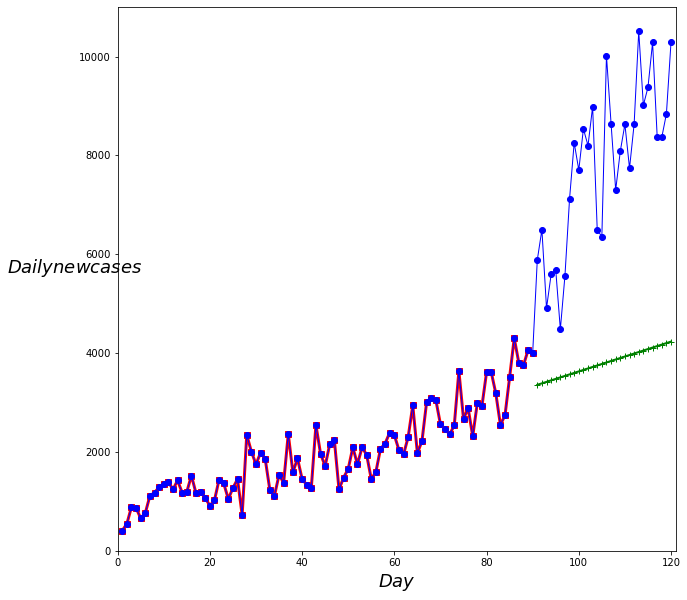

In [446]:
plt.figure(figsize=(10,10))
plt.plot(X_train,y_train, "r-s", linewidth=3,label="Training Data")
plt.plot(X_valid,y_predict1, "g-+", linewidth=2, label="Validataion Data")
plt.plot(Xcovid,data, "b-o", linewidth=1, label="Data")
plt.xlabel("$Day$", fontsize=18)
plt.ylabel("$Daily new cases$", rotation=0, fontsize=18)
plt.axis([0, 121, 0, 11000])
plt.show() 

c) compute optimal solution by mini-batch (size 10) stochastic gradient descent

In [451]:
m=120
n_epochs = 50
eta = 0.001
minibatch_size = 10
theta = np.random.randn(2,1) 
theta_path_sgd_nols = []
for epoch in range(n_epochs):
    for i in range(0, m, minibatch_size):
        if epoch == 0 and i < 20: 
            y_predict3 = X_new_b.dot(theta)
        random_index = np.random.randint(m) 
        xi = X_b[random_index:random_index+1]   
        yi = data[random_index:random_index+1]  
        gradients = (2/minibatch_size) * xi.T.dot(xi.dot(theta) - yi) 
        theta = theta - eta * gradients
        theta_path_sgd_nols.append(theta) 

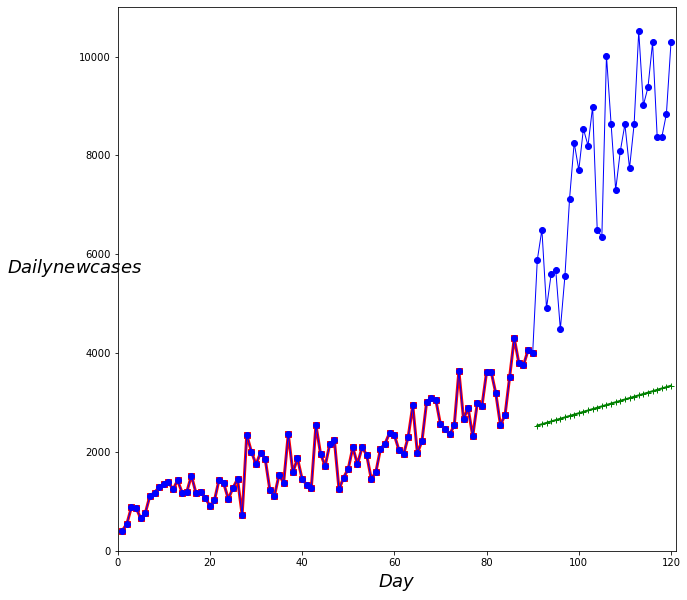

In [452]:
plt.figure(figsize=(10,10))
plt.plot(X_train,y_train, "r-s", linewidth=3,label="Training Data")
plt.plot(X_valid,y_predict3, "g-+", linewidth=2, label="Validataion Data")
plt.plot(Xcovid,data, "b-o", linewidth=1, label="Data")
plt.xlabel("$Day$", fontsize=18)
plt.ylabel("$Daily new cases$", rotation=0, fontsize=18)
plt.axis([0, 121, 0, 11000])
plt.show() 

In [442]:
print(np.sqrt(mean_squared_error(y_valid, y_predict3)))

7696.379355801778


#### Question 3

Repeat Problem 2 for quadratic polynomial regressionmodel.